# EDA — WC 2026 Fixtures & Live Results
**Sources**: 
- `openfootball_2026/worldcup_2026.json` — 104 fixtures with results where played
- `wc2026_results/` — unofficial Kaggle dataset: `teams.csv`, `matches.csv`, `tournament_stages.csv`, `host_cities.csv`, SQLite DB

**Purpose**: Understand the fixture structure, which matches have been played, group standings, and what prediction targets remain. This is the submission target dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sqlite3
from pathlib import Path
import datetime

sns.set_theme(style='whitegrid', palette='muted')
OF_DATA = Path('../data/raw/openfootball_2026')
WC_DATA = Path('../data/raw/wc2026_results')
TODAY = datetime.date(2026, 6, 12)

## 1. OpenFootball — Load & Parse

In [2]:
with open(OF_DATA / 'worldcup_2026.json') as f:
    wc_json = json.load(f)

print('Top-level keys:', list(wc_json.keys()))
print('Tournament name:', wc_json.get('name'))
print('Total matches in JSON:', len(wc_json['matches']))
print('\nSample match:')
print(json.dumps(wc_json['matches'][0], indent=2))

Top-level keys: ['name', 'matches']
Tournament name: World Cup 2026
Total matches in JSON: 104

Sample match:
{
  "round": "Matchday 1",
  "date": "2026-06-11",
  "time": "13:00 UTC-6",
  "team1": "Mexico",
  "team2": "South Africa",
  "score": {
    "ft": [
      2,
      0
    ],
    "ht": [
      1,
      0
    ]
  },
  "goals1": [
    {
      "name": "Juli\u00e1n Qui\u00f1ones",
      "minute": "9"
    },
    {
      "name": "Ra\u00fal Jim\u00e9nez",
      "minute": "67"
    }
  ],
  "goals2": [],
  "group": "Group A",
  "ground": "Mexico City"
}


In [3]:
rows = []
for m in wc_json['matches']:
    score = m.get('score', {})
    ft = score.get('ft', [None, None])
    ht = score.get('ht', [None, None])
    rows.append({
        'round': m.get('round'),
        'date': m.get('date'),
        'time': m.get('time'),
        'team1': m.get('team1'),
        'team2': m.get('team2'),
        'group': m.get('group'),
        'ground': m.get('ground'),
        'home_score_ft': ft[0] if ft else None,
        'away_score_ft': ft[1] if ft else None,
        'home_score_ht': ht[0] if ht else None,
        'away_score_ht': ht[1] if ht else None,
        'goals1': len(m.get('goals1', [])),
        'goals2': len(m.get('goals2', [])),
    })

fixtures = pd.DataFrame(rows)
fixtures['date'] = pd.to_datetime(fixtures['date'])
fixtures['played'] = fixtures['home_score_ft'].notna()
print('Fixtures shape:', fixtures.shape)
print('Matches played:', fixtures['played'].sum())
print('Matches remaining:', (~fixtures['played']).sum())
fixtures.head(5)

Fixtures shape: (104, 14)
Matches played: 2
Matches remaining: 102


,round,date,time,team1,team2,group,ground,home_score_ft,away_score_ft,home_score_ht,away_score_ht,goals1,goals2,played
0,Matchday 1,2026-06-11,13:00 UTC-6,Mexico,South Africa,Group A,Mexico City,2.0,0.0,1.0,0.0,2,0,True
1,Matchday 1,2026-06-11,20:00 UTC-6,South Korea,Czech Republic,Group A,Guadalajara (Zapopan),2.0,1.0,0.0,0.0,2,1,True
2,Matchday 8,2026-06-18,12:00 UTC-4,Czech Republic,South Africa,Group A,Atlanta,NaN,NaN,NaN,NaN,0,0,False
3,Matchday 8,2026-06-18,19:00 UTC-6,Mexico,South Korea,Group A,Guadalajara (Zapopan),NaN,NaN,NaN,NaN,0,0,False
4,Matchday 14,2026-06-24,19:00 UTC-6,Czech Republic,Mexico,Group A,Mexico City,NaN,NaN,NaN,NaN,0,0,False


## 2. Tournament Structure

In [4]:
print('Rounds:')
print(fixtures['round'].value_counts())
print()
print('Groups:')
group_stage = fixtures[fixtures['group'].notna()]
print(group_stage['group'].value_counts().sort_index())
print()
print('Venues (top 10):')
print(fixtures['ground'].value_counts().head(10))

Rounds:
round
Round of 32              16
Round of 16               8
Matchday 14               6
Matchday 15               6
Matchday 16               6
Matchday 17               6
Matchday 8                4
Matchday 3                4
Matchday 9                4
Matchday 4                4
Matchday 10               4
Matchday 5                4
Matchday 11               4
Matchday 6                4
Matchday 12               4
Matchday 7                4
Matchday 13               4
Quarter-final             4
Matchday 1                2
Matchday 2                2
Semi-final                2
Match for third place     1
Final                     1
Name: count, dtype: int64

Groups:
group
Group A    6
Group B    6
Group C    6
Group D    6
Group E    6
Group F    6
Group G    6
Group H    6
Group I    6
Group J    6
Group K    6
Group L    6
Name: count, dtype: int64

Venues (top 10):
ground
Dallas (Arlington)                       9
Atlanta                                  8
Los Ange

## 3. Played Matches — Score Distribution

Played matches: 2
Date range: 2026-06-11 -> 2026-06-11


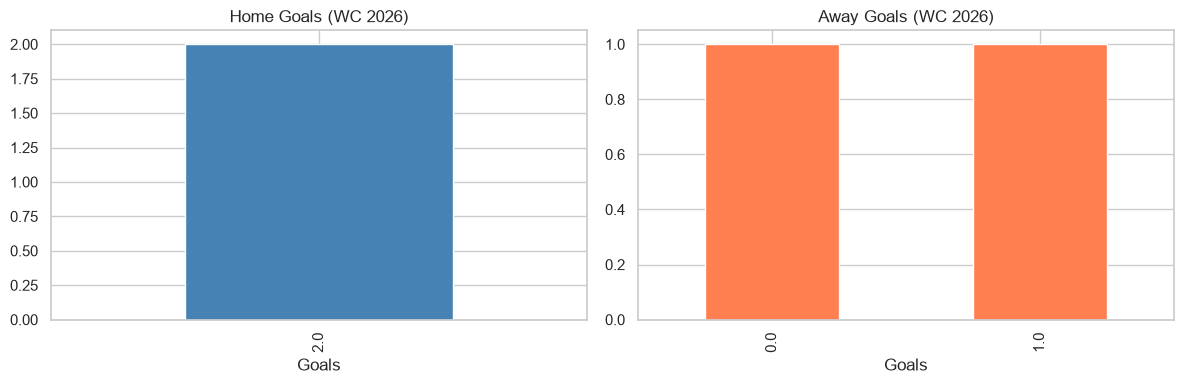

Mean home goals: 2.00
Mean away goals: 0.50
Results so far: Counter({'team1_win': 2})


In [5]:
played = fixtures[fixtures['played']].copy()
print(f'Played matches: {len(played)}')
print(f'Date range: {played["date"].min().date()} -> {played["date"].max().date()}')

if len(played) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, col, label, color in [
        (axes[0], 'home_score_ft', 'Home Goals (WC 2026)', 'steelblue'),
        (axes[1], 'away_score_ft', 'Away Goals (WC 2026)', 'coral')
    ]:
        played[col].value_counts().sort_index().plot(kind='bar', ax=ax, color=color)
        ax.set_title(label)
        ax.set_xlabel('Goals')

    plt.tight_layout()
    plt.show()

    print(f'Mean home goals: {played["home_score_ft"].mean():.2f}')
    print(f'Mean away goals: {played["away_score_ft"].mean():.2f}')
    
    results_so_far = []
    for _, r in played.iterrows():
        if r.home_score_ft > r.away_score_ft:
            results_so_far.append('team1_win')
        elif r.home_score_ft == r.away_score_ft:
            results_so_far.append('draw')
        else:
            results_so_far.append('team2_win')
    from collections import Counter
    print('Results so far:', Counter(results_so_far))

## 4. Group Stage Progress

In [6]:
group_played = group_stage[group_stage['played']]
group_remaining = group_stage[~group_stage['played']]

print(f'Group stage matches played: {len(group_played)} / {len(group_stage)}')
print(f'Group stage matches remaining: {len(group_remaining)}')
print()
print('Group stage progress:')
progress = group_stage.groupby('group').agg(
    total=('played', 'count'),
    played=('played', 'sum')
).assign(remaining=lambda x: x.total - x.played)
print(progress.sort_index())

Group stage matches played: 2 / 72
Group stage matches remaining: 70

Group stage progress:
         total  played  remaining
group                            
Group A      6       2          4
Group B      6       0          6
Group C      6       0          6
Group D      6       0          6
Group E      6       0          6
Group F      6       0          6
Group G      6       0          6
Group H      6       0          6
Group I      6       0          6
Group J      6       0          6
Group K      6       0          6
Group L      6       0          6


## 5. Upcoming Matches (Prediction Targets)

In [7]:
remaining = fixtures[~fixtures['played']].sort_values('date')
print(f'Total remaining fixtures to predict: {len(remaining)}')
print()
print('Next 10 upcoming matches:')
print(remaining[['date', 'round', 'group', 'team1', 'team2', 'ground']].head(10).to_string(index=False))

print()
print('Remaining by stage:')
def classify_stage(row):
    if pd.notna(row['group']):
        return 'Group stage'
    return row['round'] if pd.notna(row['round']) else 'Unknown'

remaining['stage'] = remaining.apply(classify_stage, axis=1)
print(remaining['stage'].value_counts())

Total remaining fixtures to predict: 102

Next 10 upcoming matches:
      date      round   group       team1                team2                                ground
2026-06-12 Matchday 2 Group D         USA             Paraguay               Los Angeles (Inglewood)
2026-06-12 Matchday 2 Group B      Canada Bosnia & Herzegovina                               Toronto
2026-06-13 Matchday 3 Group C      Brazil              Morocco New York/New Jersey (East Rutherford)
2026-06-13 Matchday 3 Group D   Australia               Turkey                             Vancouver
2026-06-13 Matchday 3 Group B       Qatar          Switzerland  San Francisco Bay Area (Santa Clara)
2026-06-13 Matchday 3 Group C       Haiti             Scotland                   Boston (Foxborough)
2026-06-14 Matchday 4 Group F      Sweden              Tunisia                 Monterrey (Guadalupe)
2026-06-14 Matchday 4 Group E Ivory Coast              Ecuador                          Philadelphia
2026-06-14 Matchday 4 G

## 6. Unofficial Kaggle Dataset — Cross-check

In [8]:
teams_df = pd.read_csv(WC_DATA / 'teams.csv')
matches_df = pd.read_csv(WC_DATA / 'matches.csv')
stages_df = pd.read_csv(WC_DATA / 'tournament_stages.csv')
cities_df = pd.read_csv(WC_DATA / 'host_cities.csv')

print('Teams:', teams_df.shape)
print(teams_df.head())
print()
print('Matches:', matches_df.shape)
print(matches_df.head())
print()
print('Stages:', stages_df)
print()
print('Cities:', cities_df.shape)
print(cities_df.head())

Teams: (48, 5)
   id              team_name fifa_code group_letter  is_placeholder
0   1                 Mexico       MEX            A           False
1   2           South Africa       RSA            A           False
2   3            South Korea       KOR            A           False
3   4  Winner UEFA Playoff D      UEPD            A            True
4   5                 Canada       CAN            B           False

Matches: (104, 8)
   id  match_number  home_team_id  away_team_id  city_id  stage_id  \
0   1             1           1.0           2.0       15         1   
1   2             2           3.0           4.0       14         1   
2   3             3           5.0           6.0       12         1   
3   4             4          13.0          14.0        6         1   
4   5             5           7.0           8.0       10         1   

               kickoff_at match_label  
0  2026-06-11 15:00:00-06     Group A  
1  2026-06-11 22:00:00-06     Group A  
2  2026-06-12 15:

In [9]:
# SQLite DB check
conn = sqlite3.connect(WC_DATA / 'worldcup2026.db')
tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()
print('SQLite tables:', [t[0] for t in tables])
for t_name, in tables:
    df = pd.read_sql(f'SELECT * FROM {t_name} LIMIT 3', conn)
    print(f'\n{t_name}:', df.shape)
    print(df)
conn.close()

SQLite tables: ['host_cities', 'tournament_stages', 'teams', 'matches']

host_cities: (3, 6)
   id city_name country             venue_name region_cluster airport_code
0   1   Atlanta     USA  Mercedes-Benz Stadium           East          ATL
1   2    Boston     USA       Gillette Stadium           East          BOS
2   3    Dallas     USA           AT&T Stadium        Central          DAL

tournament_stages: (3, 3)
   id   stage_name  stage_order
0   1  Group Stage            1
1   2  Round of 32            2
2   3  Round of 16            3

teams: (3, 5)
   id     team_name fifa_code group_letter  is_placeholder
0   1        Mexico       MEX            A               0
1   2  South Africa       RSA            A               0
2   3   South Korea       KOR            A               0

matches: (3, 8)
   id  match_number  home_team_id  away_team_id  city_id  stage_id  \
0   1             1             1             2       15         1   
1   2             2             3           

In [10]:
# Teams coverage check: does Kaggle dataset have all 48 teams?
kaggle_teams = set(teams_df[teams_df['is_placeholder'] == 0]['team_name'].tolist())
openfootball_teams = set(fixtures['team1'].tolist() + fixtures['team2'].tolist())

print('Teams in Kaggle dataset (non-placeholder):', len(kaggle_teams))
print('Teams in OpenFootball:', len(openfootball_teams))
print()
in_kaggle_not_of = kaggle_teams - openfootball_teams
in_of_not_kaggle = openfootball_teams - kaggle_teams
if in_kaggle_not_of:
    print('In Kaggle but not OpenFootball:', sorted(in_kaggle_not_of)[:10])
if in_of_not_kaggle:
    print('In OpenFootball but not Kaggle:', sorted(in_of_not_kaggle)[:10])
print('Note: Name mismatches expected — need harmonization before model training')

Teams in Kaggle dataset (non-placeholder): 42
Teams in OpenFootball: 112

In Kaggle but not OpenFootball: ['Cabo Verde', "Côte d'Ivoire", 'IR Iran']
In OpenFootball but not Kaggle: ['1A', '1B', '1C', '1D', '1E', '1F', '1G', '1H', '1I', '1J']
Note: Name mismatches expected — need harmonization before model training


## 7. Red Flags Summary

In [11]:
red_flags = []

if len(played) == 0:
    red_flags.append('OpenFootball JSON shows no played matches — may need manual update')

if in_of_not_kaggle:
    red_flags.append(f'Team name mismatches between OpenFootball and Kaggle: {sorted(in_of_not_kaggle)[:5]} — need harmonization table')

placeholder_count = (teams_df['is_placeholder'] == 1).sum()
if placeholder_count > 0:
    red_flags.append(f'Kaggle dataset has {placeholder_count} placeholder teams (knockout TBDs) — expected for group stage')

if red_flags:
    print('RED FLAGS:')
    for f in red_flags:
        print(' -', f)
else:
    print('No red flags — fixture data looks complete.')

RED FLAGS:
 - Team name mismatches between OpenFootball and Kaggle: ['1A', '1B', '1C', '1D', '1E'] — need harmonization table
 - Kaggle dataset has 6 placeholder teams (knockout TBDs) — expected for group stage
